<a href="https://colab.research.google.com/github/muhammad-afrizal/bisindo-app/blob/main/%5Bskripsi%5D_BISINDO_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Downlad dan Ekstrak Dataset**



*   dataset menggunakan google drive dan diekstrak menggunakan zipfile

*   [bisindo-dataset-skripsi](https://drive.google.com/file/d/1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m/view?usp=sharing/)




In [14]:
# https://drive.google.com/file/d/1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m/view?usp=sharing/

!pip install gdown

# 1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m

file_id = "1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m"
output_file = "bisindo-dataset.zip"

!gdown --id $file_id -O $output_file

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m
From (redirected): https://drive.google.com/uc?id=1awcUihl76S9jIk2S-TgwOiRUZ1wTz41m&confirm=t&uuid=612e0b9c-ca96-4dfe-b612-9dddf4a88db9
To: /content/bisindo-dataset.zip
100% 95.1M/95.1M [00:00<00:00, 167MB/s]


In [15]:
import zipfile

# Extract the archive
local_zip = './bisindo-dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('tmp/')
zip_ref.close()

# **Make Train and Validation Folder**

In [16]:
import os

base_dir = 'tmp/DATASET SKRIPSI'
for char in range(ord('A'), ord('Z') + 1):
    dir_path = os.path.join(base_dir, chr(char))
    files = os.listdir(dir_path)
    print(f'{chr(char)} files:', files[:5])

A files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
B files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
C files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
D files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
E files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
F files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
G files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
H files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
I files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
J files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
K files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
L files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
M files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
N files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
O files: ['204.jpg', '170.jpg', '12.jpg', '187.jpg', '269.jpg']
P files: ['204.jpg', '170.jpg', '12.jpg'

# **Split Dataset**

In [17]:
import shutil
root_dir = 'data/'

if os.path.exists(root_dir):
    shutil.rmtree(root_dir)

def create_train_val_dirs(root_path):
    os.makedirs(os.path.join(root_path, 'training'))
    os.makedirs(os.path.join(root_path, 'validation'))
    for char in range(ord('A'), ord('Z') + 1):
        os.makedirs(os.path.join(root_path, 'training', chr(char)))
        os.makedirs(os.path.join(root_path, 'validation', chr(char)))

try:
  create_train_val_dirs(root_path=root_dir)
except FileExistsError:
  print("You should not be seeing this since the upper directory is removed beforehand")

In [18]:
# Test create_train_val_dirs function
for rootdir, dirs, files in os.walk(root_dir):
    for subdir in dirs:
        print(os.path.join(rootdir, subdir))

data/training
data/validation
data/training/X
data/training/P
data/training/G
data/training/V
data/training/R
data/training/N
data/training/B
data/training/U
data/training/Z
data/training/E
data/training/Y
data/training/I
data/training/F
data/training/S
data/training/T
data/training/Q
data/training/J
data/training/A
data/training/L
data/training/D
data/training/H
data/training/C
data/training/M
data/training/O
data/training/K
data/training/W
data/validation/X
data/validation/P
data/validation/G
data/validation/V
data/validation/R
data/validation/N
data/validation/B
data/validation/U
data/validation/Z
data/validation/E
data/validation/Y
data/validation/I
data/validation/F
data/validation/S
data/validation/T
data/validation/Q
data/validation/J
data/validation/A
data/validation/L
data/validation/D
data/validation/H
data/validation/C
data/validation/M
data/validation/O
data/validation/K
data/validation/W


# **Augmentasi Data**

In [19]:
from shutil import copyfile

def split_data(source_dir, training_dir):
    shuffled_source = random.sample(os.listdir(source_dir), len(os.listdir(source_dir)))
    training_number = int(len(shuffled_source) * split_size)
    i = 0
    for item in shuffled_source:
        item_source = os.path.join(source_dir, item)
        if os.path.getsize(item_source) == 0:
            print(f'{item} is zero length, so ignoring.')
        else:
          copyfile(item_source, os.path.join(train, item))
        i += 1
        if i == training_number:
            target= validation_dir

In [20]:
import os

source_dir = 'tmp/DATASET SKRIPSI'
training_dir = 'data/training'
validation_dir = 'data/validation'

for char in range(ord('A'), ord('Z') + 1):
    label = chr(char).lower()
    source_path = os.path.join(source_dir, label)
    training_path = os.path.join(training_dir, label)
    validation_path = os.path.join(validation_dir, label)

    print(f'Source: {source_path}')
    print(f'Training: {training_path}')
    print(f'Validation: {validation_path}')

Source: tmp/DATASET SKRIPSI/a
Training: data/training/a
Validation: data/validation/a
Source: tmp/DATASET SKRIPSI/b
Training: data/training/b
Validation: data/validation/b
Source: tmp/DATASET SKRIPSI/c
Training: data/training/c
Validation: data/validation/c
Source: tmp/DATASET SKRIPSI/d
Training: data/training/d
Validation: data/validation/d
Source: tmp/DATASET SKRIPSI/e
Training: data/training/e
Validation: data/validation/e
Source: tmp/DATASET SKRIPSI/f
Training: data/training/f
Validation: data/validation/f
Source: tmp/DATASET SKRIPSI/g
Training: data/training/g
Validation: data/validation/g
Source: tmp/DATASET SKRIPSI/h
Training: data/training/h
Validation: data/validation/h
Source: tmp/DATASET SKRIPSI/i
Training: data/training/i
Validation: data/validation/i
Source: tmp/DATASET SKRIPSI/j
Training: data/training/j
Validation: data/validation/j
Source: tmp/DATASET SKRIPSI/k
Training: data/training/k
Validation: data/validation/k
Source: tmp/DATASET SKRIPSI/l
Training: data/training/

In [47]:
import os

training_dir = "data/training"
validation_dir = "data/validation"

# Loop untuk membersihkan folder A-Z
for char in range(ord('A'), ord('Z') + 1):
    label = chr(char).lower()  # Mengubah huruf menjadi lowercase sesuai dengan nama folder

    # Direktori training & validation
    training_path = os.path.join(training_dir, label)
    validation_path = os.path.join(validation_dir, label)

    # Hapus semua file di direktori training
    if os.path.exists(training_path) and len(os.listdir(training_path)) > 0:
        for file in os.scandir(training_path):
            os.remove(file.path)

    # Hapus semua file di direktori validation
    if os.path.exists(validation_path) and len(os.listdir(validation_path)) > 0:
        for file in os.scandir(validation_path):
            os.remove(file.path)

print("Semua direktori training dan validation telah dikosongkan.")


Semua direktori training dan validation telah dikosongkan.


Rescale, Width Shift Range, Height Shift Range, Zoom Range, Brightness Range, fill Mode, Shear Range, Contrast Adjustment, Gaussian Blur

In [48]:
from posixpath import split
split_size = .8

In [49]:
import os
import shutil

def split_data(source_dir, training_dir, validation_dir, split_size):
    """Membagi dataset menjadi training dan validation berdasarkan split_size"""
    files = os.listdir(source_dir)
    files = [f for f in files if os.path.isfile(os.path.join(source_dir, f))]  # Hanya file, bukan folder
    total_files = len(files)

    if total_files == 0:
        print(f"Warning: {source_dir} tidak memiliki gambar!")
        return

    split_point = int(total_files * split_size)  # Menentukan batas split
    train_files = files[:split_point]
    val_files = files[split_point:]

    for file in train_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(train_dir, file))

    for file in val_files:
        shutil.copy(os.path.join(source_dir, file), os.path.join(val_dir, file))

# Path utama dataset
base_source_dir = "tmp/DATASET SKRIPSI"
train_base_dir = "data/training"
val_base_dir = "data/validation"
split_size = 0.8  # 80% training, 20% validation

# Loop untuk huruf A-Z
for letter in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
    source_dir = os.path.join(base_source_dir, letter)
    train_dir = os.path.join(train_base_dir, letter)
    val_dir = os.path.join(val_base_dir, letter)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    split_data(source_dir, train_dir, val_dir, split_size)

# Cek jumlah gambar setelah split
print("\n==== DATASET SPLIT CHECK ====\n")

print("=== TRAINING SET ===")
for letter in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
    print(f"Training {letter} has {len(os.listdir(os.path.join(train_base_dir, letter)))} images")

print("\n=== VALIDATION SET ===")
for letter in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
    print(f"Validation {letter} has {len(os.listdir(os.path.join(val_base_dir, letter)))} images")



==== DATASET SPLIT CHECK ====

=== TRAINING SET ===
Training A has 248 images
Training B has 248 images
Training C has 248 images
Training D has 248 images
Training E has 248 images
Training F has 248 images
Training G has 248 images
Training H has 248 images
Training I has 248 images
Training J has 248 images
Training K has 248 images
Training L has 248 images
Training M has 248 images
Training N has 248 images
Training O has 248 images
Training P has 248 images
Training Q has 248 images
Training R has 248 images
Training S has 248 images
Training T has 248 images
Training U has 248 images
Training V has 248 images
Training W has 248 images
Training X has 248 images
Training Y has 248 images
Training Z has 248 images

=== VALIDATION SET ===
Validation A has 62 images
Validation B has 62 images
Validation C has 62 images
Validation D has 62 images
Validation E has 62 images
Validation F has 62 images
Validation G has 62 images
Validation H has 62 images
Validation I has 62 images
Vali

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path direktori dataset
training_dir = "data/training"
validation_dir = "data/validation"

# Augmentasi untuk training dataset
training_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisasi pixel
    width_shift_range=0.2,  # Geser horizontal max 20% dari lebar gambar
    height_shift_range=0.2,  # Geser vertikal max 20% dari tinggi gambar
    zoom_range=0.2,  # Zoom in/out max 20%
    brightness_range=[0.8, 1.2],  # Ubah kecerahan dalam rentang 80% - 120%
    shear_range=0.2,  # Distorsi miring (shear) max 20%
    fill_mode='nearest'  # Mengisi pixel kosong akibat transformasi
)

# Hanya rescale untuk validation dataset (tanpa augmentasi)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Generator untuk training set
train_generator = training_datagen.flow_from_directory(
    training_dir,
    target_size=(280, 280),
    class_mode='categorical',  # Klasifikasi multi-kelas A-Z
    batch_size=128
)

# Generator untuk validation set
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(280, 280),
    class_mode='categorical',  # Klasifikasi multi-kelas A-Z
    batch_size=128
)

# Cek jumlah kelas yang dikenali
print("\nClasses recognized in training:", train_generator.class_indices)
print("Classes recognized in validation:", validation_generator.class_indices)


Found 6448 images belonging to 26 classes.
Found 1612 images belonging to 26 classes.

Classes recognized in training: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}
Classes recognized in validation: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


# **Modeling**

In [64]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential()
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(280, 280, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3,3), activation = 'relu', input_shape=(28, 28,1)))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense (128, activation = 'relu'))
model.add(Dropout (0.20))
model.add(Dense (26, activation = 'softmax'))
model.compile(loss = 'categorical_crossentropy',
              optimizer= Adam(),
              metrics=['accuracy'])



In [65]:
import tensorflow as tf
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',  # Pantau loss validasi untuk menghentikan training
        patience=5,  # Tunggu 5 epoch tanpa peningkatan sebelum berhenti
        restore_best_weights=True  # Kembalikan bobot terbaik sebelum overfitting
    )
]

In [66]:
# Melatih model menggunakan data generator
history = model.fit(
    train_generator,  # Data training dari ImageDataGenerator
    validation_data=validation_generator,  # Data validasi
    epochs=5,  # Sesuaikan jumlah epoch sesuai kebutuhan
    batch_size=128,  # Tidak diperlukan dalam fit(), karena sudah diatur di ImageDataGenerator
    verbose=1  # Menampilkan progress training
)

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 1781s 35s/step - accuracy: 0.0361 - loss: 3.2598 - val_accuracy: 0.0806 - val_loss: 3.1981
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 1799s 35s/step - accuracy: 0.0762 - loss: 3.1955 - val_accuracy: 0.2270 - val_loss: 2.7700
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 1805s 35s/step - accuracy: 0.1463 - loss: 2.9636 - val_accuracy: 0.3071 - val_loss: 2.5011
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 1769s 35s/step - accuracy: 0.1945 - loss: 2.7717 - val_accuracy: 0.3952 - val_loss: 2.1405
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 1773s 35s/step - accuracy: 0.2614 - loss: 2.5399 - val_accuracy: 0.5000 - val_loss: 1.8692


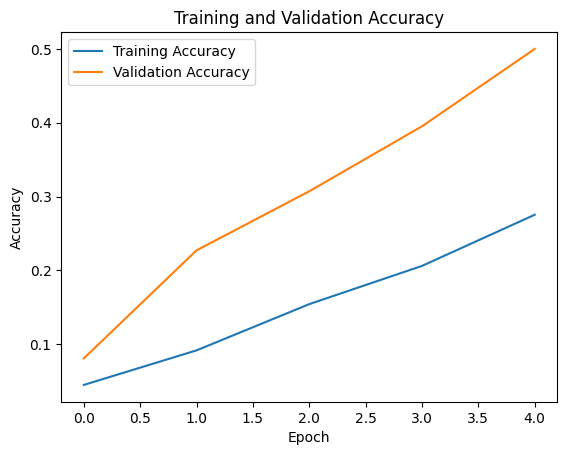

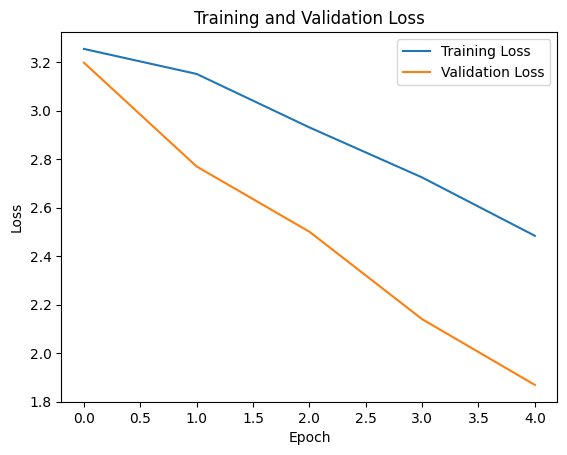

In [67]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [68]:
test_loss, test_acc = model.evaluate(validation_generator)
print(f'\nTest accuracy: {test_acc}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 119s 9s/step - accuracy: 0.4882 - loss: 1.8870

Test accuracy: 0.5


testing

In [70]:
model.save("model_alphabet.h5")
print("Model berhasil disimpan dalam format H5!")

Model berhasil disimpan dalam format H5!


In [71]:
import tensorflow as tf

# Muat kembali model H5
model = tf.keras.models.load_model("model_alphabet.h5")

# Konversi ke format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TFLite
with open("model_alphabet.tflite", "wb") as f:
    f.write(tflite_model)

print("Model berhasil dikonversi ke format TFLite!")


Saved artifact at '/tmp/tmpbdtuaz2b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 280, 280, 3), dtype=tf.float32, name='input_layer_9')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  136352597948560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597937232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597938000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597950288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597949904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597946448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597946256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597944720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597946640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597945488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136352597949

In [69]:
test_labels = test['label']
test.drop('label', axis = 1, inplace = True)
test_images = test.values
test_images = np.array([np.reshape(i, (28, 28)) for i in test_images])
test_images = np.array([i.flatten() for i in test_images])
test_labels = label_binrizer.fit_transform(test_labels)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)
test_images.shape
y_pred = model.predict(test_images)

NameError: name 'test' is not defined

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(test_labels, y_pred.round())

In [ ]:
def getLetter(result):
    classLabels = { 0:'A',
                    1:'B',
                    2:'C',
                    3:'D',
                    4:'E',
                    5:'F',
                    6:'G',
                    7:'H',
                    8:'I',
                    9:'K',
                    10:'L',
                    11:'M',
                    12:'N',
                    13:'0',
                    14:'P',
                    15:'Q',
                    16:'R',
                    17:'S',
                    18:'T',
                    19:'U',
                    20:'V',
                    21:'W',
                    22:'X',
                    23:'Y'}
    try:
        res = int(result)
        return classLabels[res]
    except:
      return "Error"